<div style="background: #1a1a1a; padding: 30px; text-align: center; border-radius: 8px;">
    <div style="font-size: 32px; font-weight: bold; margin-bottom: 15px; background: linear-gradient(135deg, rgb(111, 66, 193) 0%, rgba(167, 245, 255, 0.97) 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">Mini-Project 3: Advanced Data Mining</div>
    <div style="font-size: 18px; font-weight: bold; margin-bottom: 3px; color: #ddd;">TF — Transformer Text Classification on AG News</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Task:</strong> fine-tune a pretrained DistilBERT encoder for topic classification and compare it with a TF-IDF + Logistic Regression baseline.</div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Dataset:</strong> AG News — four news-topic classes.</div>
    <div style="font-size: 16px; margin-bottom: 12px; color: #ddd;"><strong>Original Contribution — Hypothesis</strong></div>
    <div style="background: rgba(255,255,255,0.05); border-left: 3px solid rgb(111, 66, 193); padding: 15px 20px; margin: 10px 0 8px 0; border-radius: 4px; text-align: left;">
        <div style="font-size: 15px; margin-bottom: 8px; color: #ddd; font-style: italic; line-height: 1.6;">"A pretrained contextual Transformer should preserve stronger macro-F1 than TF-IDF when labeled training data is limited, and should beat the classical baseline at the largest training budget."</div>
        <div style="font-size: 13px; color: #aaa; line-height: 1.5;">Data-Efficiency Study comparing TF-IDF and DistilBERT across increasing labeled-data budgets.</div>
    </div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;"><strong>Stretch / bonus:</strong> Calibration analysis with temperature scaling.</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Professor: Dr. Hadi Farahani</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Head TA: Mr. Mobin Nesari</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;">Student: Alireza Jahanbakhsh</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 14px; color: #aaa;">Date: August 13, 2026 | Course: Data Mining</div>
</div>


# TF — Transformer Text Classification on AG News

## 1. Problem and Experimental Design

### 1.1 Research design
We classify AG News articles into four topics using a classical baseline and a fine-tuned pretrained Transformer. The main comparison uses accuracy, macro-F1, per-class metrics, and representative error cases.

### 1.2 Original contribution and hypothesis
The original contribution is a controlled **data-efficiency curve**. Both TF-IDF and DistilBERT are trained on the same stratified training subsets, so the experiment tests how each method behaves as labeled data increases.

In [1]:
import os
import random
import shutil
import subprocess
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
FIG_DIR = os.path.join(BASE_DIR, "figures")
RES_DIR = os.path.join(BASE_DIR, "results")
MODEL_DIR = os.path.join(BASE_DIR, "models")

for directory in [FIG_DIR, RES_DIR, MODEL_DIR]:
    if os.path.exists(directory):
        shutil.rmtree(directory)
    os.makedirs(directory, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=180, bbox_inches="tight")

In [2]:
def ensure_package(package, import_name=None):
    name = import_name or package
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

ensure_package("datasets")
ensure_package("transformers")
ensure_package("accelerate")

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, log_loss
from scipy.special import softmax
from scipy.stats import binomtest

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Data Loading and Preprocessing

### 2.1 Dataset overview
AG News is a four-class news-topic classification dataset. We use the official train/test split and create a stratified validation split from the training set.

In [4]:
dataset = load_dataset("ag_news")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

label_names = dataset["train"].features["label"].names
label_map = dict(enumerate(label_names))

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Labels:", label_map)
train_df.head()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: (120000, 2)
Test : (7600, 2)
Labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


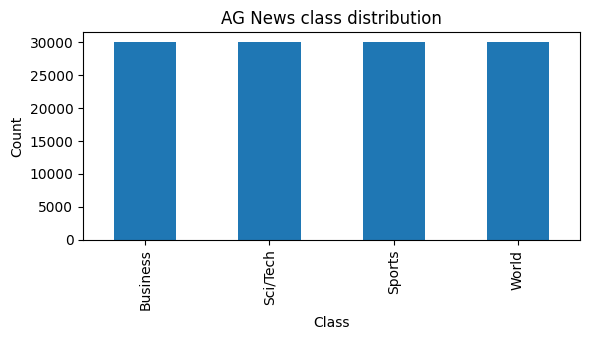

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
train_df["label"].map(label_map).value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("AG News class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
savefig("01_class_distribution.png")
plt.show()

### 2.2 Train/validation split
The official test set is kept untouched until the final 8,000-example comparison. Validation is used for the data-efficiency study, model selection within each Transformer run, and temperature scaling.


In [6]:
train_part, val_part = train_test_split(
    train_df,
    test_size=0.10,
    stratify=train_df["label"],
    random_state=SEED
)

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training pool:", train_part.shape)
print("Validation   :", val_part.shape)
print("Test         :", test_df.shape)

Training pool: (108000, 2)
Validation   : (12000, 2)
Test         : (7600, 2)


### 2.3 Stratified training subsets
The data-efficiency experiment uses the same subset sizes for both TF-IDF and DistilBERT.

In [7]:
TRAIN_SIZES = [500, 2000, 8000]
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 2
MODEL_NAME = "distilbert-base-uncased"

def stratified_subset(df, n, seed=SEED):
    if n >= len(df):
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    parts = []
    per_class = n // df["label"].nunique()
    remainder = n - per_class * df["label"].nunique()
    for label in sorted(df["label"].unique()):
        k = per_class + (1 if label < remainder else 0)
        part = df[df["label"] == label].sample(n=k, random_state=seed + int(label))
        parts.append(part)
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

for n in TRAIN_SIZES:
    sub = stratified_subset(train_part, n)
    print(n, dict(sub["label"].value_counts().sort_index()))

500 {0: np.int64(125), 1: np.int64(125), 2: np.int64(125), 3: np.int64(125)}
2000 {0: np.int64(500), 1: np.int64(500), 2: np.int64(500), 3: np.int64(500)}
8000 {0: np.int64(2000), 1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000)}


## 3. Classical Baseline

### 3.1 TF-IDF + Logistic Regression
This baseline represents a strong classical text-classification pipeline using lexical n-gram features.

In [8]:
def train_tfidf(train_subset):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=50000
    )
    X_train = vectorizer.fit_transform(train_subset["text"])
    X_val = vectorizer.transform(val_part["text"])

    clf = LogisticRegression(
        max_iter=1000,
        class_weight=None,
        n_jobs=-1,
        random_state=SEED
    )
    clf.fit(X_train, train_subset["label"])

    val_pred = clf.predict(X_val)
    val_prob = clf.predict_proba(X_val)

    return {
        "model": clf,
        "vectorizer": vectorizer,
        "val_pred": val_pred,
        "val_prob": val_prob
    }

def evaluate_tfidf(run, df):
    X = run["vectorizer"].transform(df["text"])
    pred = run["model"].predict(X)
    prob = run["model"].predict_proba(X)
    return {
        "pred": pred,
        "prob": prob,
        **classification_metrics(df["label"], pred)
    }

def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }


In [9]:
tfidf_runs = {}
tfidf_rows = []

for n in TRAIN_SIZES:
    subset = stratified_subset(train_part, n)
    run = train_tfidf(subset)
    tfidf_runs[n] = run

    metrics = classification_metrics(val_part["label"], run["val_pred"])
    tfidf_rows.append({
        "method": "TF-IDF + Logistic Regression",
        "train_size": n,
        **metrics
    })

tfidf_results = pd.DataFrame(tfidf_rows)
tfidf_results


,method,train_size,accuracy,macro_f1
0,TF-IDF + Logistic Regression,500,0.783917,0.783044
1,TF-IDF + Logistic Regression,2000,0.865417,0.864797
2,TF-IDF + Logistic Regression,8000,0.896167,0.895802


## 4. Transformer Baseline

### 4.1 DistilBERT fine-tuning
DistilBERT is fine-tuned under the same labeled-data budgets. The model starts from pretrained language representations rather than from scratch.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=MAX_LEN
        )
        self.input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        self.attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

def make_loader(df, batch_size=BATCH_SIZE, shuffle=False):
    ds = TextDataset(df["text"], df["label"])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
def evaluate_transformer(model, df, batch_size=64):
    model.eval()
    loader = make_loader(df, batch_size=batch_size, shuffle=False)
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits_all.append(outputs.logits.detach().cpu().numpy())
            labels_all.append(labels.detach().cpu().numpy())

    logits = np.vstack(logits_all)
    labels = np.concatenate(labels_all)
    probs = softmax(logits, axis=1)
    preds = probs.argmax(axis=1)

    return {
        "logits": logits,
        "prob": probs,
        "pred": preds,
        "labels": labels,
        **classification_metrics(labels, preds)
    }

In [12]:
def fine_tune_distilbert(train_subset, tag):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_names)
    ).to(DEVICE)

    train_loader = make_loader(train_subset, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    best_state = None
    best_val_f1 = -1
    history = []
    start = time.perf_counter()

    for epoch in range(EPOCHS):
        model.train()
        losses = []

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()

            losses.append(float(loss.detach().cpu()))

        val_eval = evaluate_transformer(model, val_part)
        history.append({
            "epoch": epoch + 1,
            "train_loss": float(np.mean(losses)),
            "val_macro_f1": val_eval["macro_f1"],
            "val_accuracy": val_eval["accuracy"]
        })

        if val_eval["macro_f1"] > best_val_f1:
            best_val_f1 = val_eval["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(tag, "epoch", epoch + 1, "loss", round(np.mean(losses), 4), "val_f1", round(val_eval["macro_f1"], 4))

    model.load_state_dict(best_state)
    elapsed = time.perf_counter() - start

    return model, pd.DataFrame(history), elapsed

In [13]:
bert_runs = {}
bert_rows = []

for n in TRAIN_SIZES:
    subset = stratified_subset(train_part, n)
    model, hist, seconds = fine_tune_distilbert(subset, f"DistilBERT-{n}")

    val_eval = evaluate_transformer(model, val_part)

    bert_runs[n] = {
        "model": model,
        "history": hist,
        "seconds": seconds,
        "val_eval": val_eval
    }

    bert_rows.append({
        "method": "DistilBERT",
        "train_size": n,
        "accuracy": val_eval["accuracy"],
        "macro_f1": val_eval["macro_f1"],
        "training_seconds": seconds
    })

bert_results = pd.DataFrame(bert_rows)
bert_results


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT-500 epoch 1 loss 1.1587 val_f1 0.8748
DistilBERT-500 epoch 2 loss 0.6072 val_f1 0.873


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBERT-2000 epoch 1 loss 0.6512 val_f1 0.8916
DistilBERT-2000 epoch 2 loss 0.3003 val_f1 0.9043


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT-8000 epoch 1 loss 0.3972 val_f1 0.9119
DistilBERT-8000 epoch 2 loss 0.2021 val_f1 0.9128


,method,train_size,accuracy,macro_f1,training_seconds
0,DistilBERT,500,0.874833,0.874816,108.913839
1,DistilBERT,2000,0.904583,0.904318,148.490467
2,DistilBERT,8000,0.912583,0.912774,293.032935


### 4.2 Training curves
The curves show whether validation performance stabilizes within the compact Kaggle training budget.

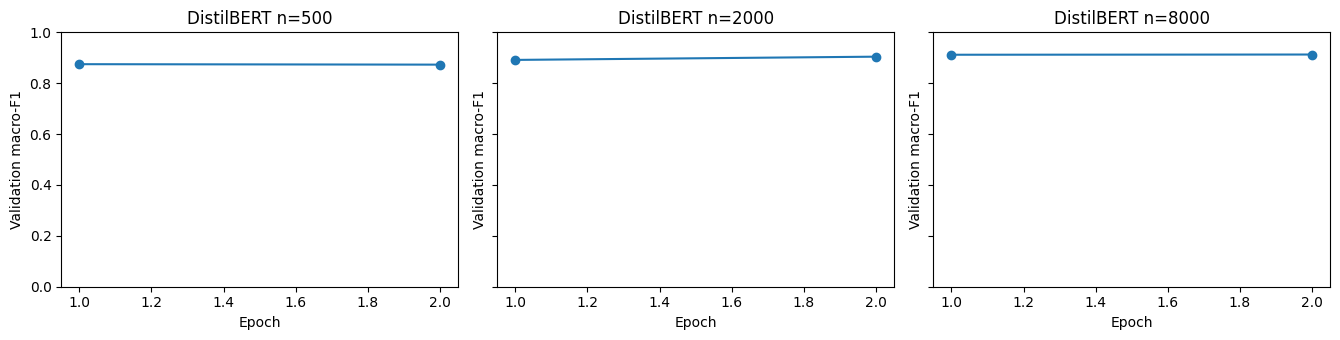

In [14]:
fig, axes = plt.subplots(1, len(TRAIN_SIZES), figsize=(4.5 * len(TRAIN_SIZES), 3.5), sharey=True)

for ax, n in zip(np.atleast_1d(axes), TRAIN_SIZES):
    hist = bert_runs[n]["history"]
    ax.plot(hist["epoch"], hist["val_macro_f1"], marker="o")
    ax.set_title(f"DistilBERT n={n}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation macro-F1")
    ax.set_ylim(0, 1)

plt.tight_layout()
savefig("02_transformer_validation_curves.png")
plt.show()

## 5. Original Contribution: Data-Efficiency Study

### 5.1 Controlled comparison
The same training subset sizes are used for TF-IDF and DistilBERT. The hypothesis is supported only if DistilBERT has stronger macro-F1 overall and beats the classical baseline at the largest training budget.

In [15]:
efficiency_df = pd.concat([tfidf_results, bert_results], ignore_index=True)
efficiency_df = efficiency_df.sort_values(["train_size", "method"]).reset_index(drop=True)
efficiency_df.to_csv(os.path.join(RES_DIR, "validation_data_efficiency_results.csv"), index=False)
efficiency_df.round(4)


,method,train_size,accuracy,macro_f1,training_seconds
0,DistilBERT,500,0.8748,0.8748,108.9138
1,TF-IDF + Logistic Regression,500,0.7839,0.7830,NaN
2,DistilBERT,2000,0.9046,0.9043,148.4905
3,TF-IDF + Logistic Regression,2000,0.8654,0.8648,NaN
4,DistilBERT,8000,0.9126,0.9128,293.0329
5,TF-IDF + Logistic Regression,8000,0.8962,0.8958,NaN


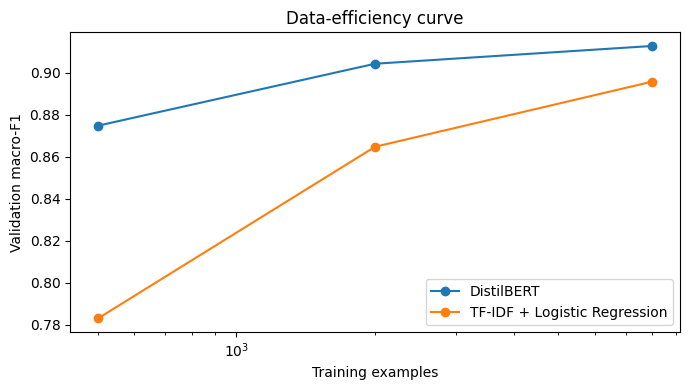

In [16]:
plt.figure(figsize=(7, 4))
for method, g in efficiency_df.groupby("method"):
    plt.plot(g["train_size"], g["macro_f1"], marker="o", label=method)

plt.xscale("log")
plt.xlabel("Training examples")
plt.ylabel("Validation macro-F1")
plt.title("Data-efficiency curve")
plt.legend()
plt.tight_layout()
savefig("03_data_efficiency_curve.png")
plt.show()


In [17]:
wide = efficiency_df.pivot(index="train_size", columns="method", values="macro_f1").reset_index()
wide["DistilBERT_minus_TFIDF"] = wide["DistilBERT"] - wide["TF-IDF + Logistic Regression"]

LOW_DATA_SIZES = [n for n in TRAIN_SIZES if n < max(TRAIN_SIZES)]
FINAL_N = max(TRAIN_SIZES)

low_data_gap = float(wide.loc[wide["train_size"].isin(LOW_DATA_SIZES), "DistilBERT_minus_TFIDF"].mean())
final_validation_gap = float(wide.loc[wide["train_size"] == FINAL_N, "DistilBERT_minus_TFIDF"].iloc[0])

hypothesis_supported_on_validation = (low_data_gap > 0) and (final_validation_gap > 0)

hypothesis_decision = pd.DataFrame([{
    "low_data_sizes": ",".join(map(str, LOW_DATA_SIZES)),
    "mean_low_data_gap_macro_f1": low_data_gap,
    "final_train_size": FINAL_N,
    "final_validation_gap_macro_f1": final_validation_gap,
    "hypothesis_supported_on_validation": hypothesis_supported_on_validation
}])

hypothesis_decision.to_csv(os.path.join(RES_DIR, "hypothesis_decision_validation.csv"), index=False)

print("VALIDATION HYPOTHESIS:", "SUPPORTED" if hypothesis_supported_on_validation else "NOT SUPPORTED")
hypothesis_decision.round(4)


VALIDATION HYPOTHESIS: SUPPORTED


,low_data_sizes,mean_low_data_gap_macro_f1,final_train_size,final_validation_gap_macro_f1,hypothesis_supported_on_validation
0,"500,2000",0.0656,8000,0.017,True


## 6. Final Evaluation

### 6.1 Final fixed-budget comparison
The 8,000-example budget is fixed in advance as the final comparison because it is the largest labeled-data budget in the study. The test set is evaluated only here, after the validation data-efficiency analysis is complete.


In [18]:
FINAL_N = max(TRAIN_SIZES)

tfidf_final = tfidf_runs[FINAL_N]
bert_final = bert_runs[FINAL_N]

tfidf_test = evaluate_tfidf(tfidf_final, test_df)
bert_test = evaluate_transformer(bert_final["model"], test_df)

tfidf_pred = tfidf_test["pred"]
tfidf_prob = tfidf_test["prob"]
bert_pred = bert_test["pred"]
bert_prob = bert_test["prob"]

final_summary = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "train_size": FINAL_N,
        "accuracy": tfidf_test["accuracy"],
        "macro_f1": tfidf_test["macro_f1"]
    },
    {
        "model": "DistilBERT",
        "train_size": FINAL_N,
        "accuracy": bert_test["accuracy"],
        "macro_f1": bert_test["macro_f1"]
    }
])

final_summary.to_csv(os.path.join(RES_DIR, "final_model_summary.csv"), index=False)
final_summary.round(4)


,model,train_size,accuracy,macro_f1
0,TF-IDF + Logistic Regression,8000,0.8913,0.8909
1,DistilBERT,8000,0.9103,0.9105


In [19]:
tfidf_report = classification_report(
    test_df["label"],
    tfidf_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

bert_report = classification_report(
    test_df["label"],
    bert_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

per_class_rows = []
for class_name in label_names:
    per_class_rows.append({
        "class": class_name,
        "tfidf_precision": tfidf_report[class_name]["precision"],
        "tfidf_recall": tfidf_report[class_name]["recall"],
        "tfidf_f1": tfidf_report[class_name]["f1-score"],
        "distilbert_precision": bert_report[class_name]["precision"],
        "distilbert_recall": bert_report[class_name]["recall"],
        "distilbert_f1": bert_report[class_name]["f1-score"],
        "delta_f1_distilbert_minus_tfidf": bert_report[class_name]["f1-score"] - tfidf_report[class_name]["f1-score"]
    })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(os.path.join(RES_DIR, "per_class_model_comparison.csv"), index=False)
per_class_df.round(4)


,class,tfidf_precision,tfidf_recall,tfidf_f1,distilbert_precision,distilbert_recall,distilbert_f1,delta_f1_distilbert_minus_tfidf
0,World,0.9039,0.8916,0.8977,0.9144,0.9105,0.9124,0.0147
1,Sports,0.9337,0.9716,0.9523,0.9824,0.9426,0.9621,0.0098
2,Business,0.8549,0.8500,0.8525,0.9024,0.8468,0.8737,0.0213
3,Sci/Tech,0.8704,0.8521,0.8612,0.8506,0.9411,0.8936,0.0324


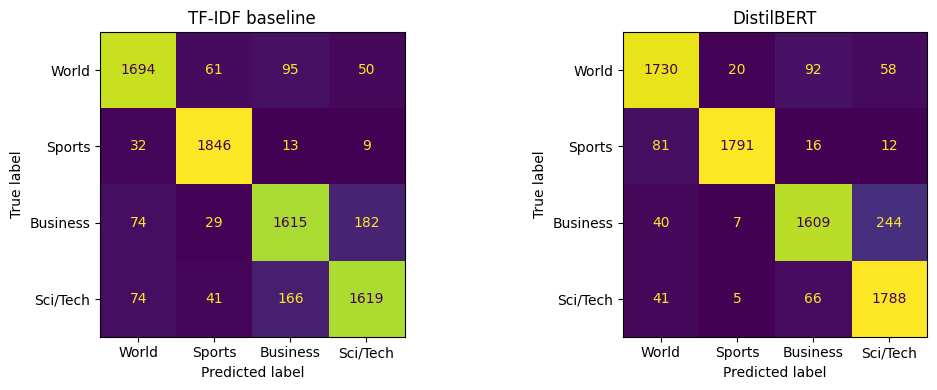

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, title in [
    (axes[0], tfidf_pred, "TF-IDF baseline"),
    (axes[1], bert_pred, "DistilBERT")
]:
    cm = confusion_matrix(test_df["label"], pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)

plt.tight_layout()
savefig("04_confusion_matrices.png")
plt.show()

### 6.2 Exact McNemar test
The exact McNemar test compares the two models on the same test examples using their discordant correctness outcomes. The unique-win counts are reported alongside the p-value so the practical direction of the difference is visible.


In [21]:
true = test_df["label"].to_numpy()

tfidf_correct = tfidf_pred == true
bert_correct = bert_pred == true

b = int((~tfidf_correct & bert_correct).sum())
c = int((tfidf_correct & ~bert_correct).sum())

if b + c > 0:
    mcnemar_p = binomtest(min(b, c), n=b + c, p=0.5).pvalue
else:
    mcnemar_p = 1.0

net_unique_wins = b - c
net_unique_win_rate = net_unique_wins / len(test_df)

paired_test = pd.DataFrame([{
    "distilbert_correct_tfidf_wrong": b,
    "tfidf_correct_distilbert_wrong": c,
    "net_unique_wins_distilbert_minus_tfidf": net_unique_wins,
    "net_unique_win_rate": net_unique_win_rate,
    "exact_mcnemar_p_two_sided": mcnemar_p
}])

paired_test.to_csv(os.path.join(RES_DIR, "exact_mcnemar_test.csv"), index=False)
paired_test.round(6)


,distilbert_correct_tfidf_wrong,tfidf_correct_distilbert_wrong,net_unique_wins_distilbert_minus_tfidf,net_unique_win_rate,exact_mcnemar_p_two_sided
0,424,280,144,0.018947,0.0


## 7. Error Analysis

### 7.1 Representative errors
We inspect examples where DistilBERT is wrong and TF-IDF is correct, and examples where TF-IDF is wrong and DistilBERT is correct.

In [22]:
error_rows = []

for i in range(len(test_df)):
    if bert_pred[i] != true[i] and tfidf_pred[i] == true[i]:
        error_rows.append({
            "case": "DistilBERT wrong, TF-IDF correct",
            "text": test_df.loc[i, "text"],
            "true_label": label_map[int(true[i])],
            "bert_pred": label_map[int(bert_pred[i])],
            "tfidf_pred": label_map[int(tfidf_pred[i])],
            "bert_confidence": float(bert_prob[i].max())
        })
    if tfidf_pred[i] != true[i] and bert_pred[i] == true[i]:
        error_rows.append({
            "case": "TF-IDF wrong, DistilBERT correct",
            "text": test_df.loc[i, "text"],
            "true_label": label_map[int(true[i])],
            "bert_pred": label_map[int(bert_pred[i])],
            "tfidf_pred": label_map[int(tfidf_pred[i])],
            "bert_confidence": float(bert_prob[i].max())
        })

error_df = pd.DataFrame(error_rows)

representative = (
    error_df
    .sort_values(["case", "true_label", "bert_confidence"], ascending=[True, True, False])
    .groupby(["case", "true_label"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

representative.to_csv(os.path.join(RES_DIR, "representative_error_cases.csv"), index=False)
representative


,case,text,true_label,bert_pred,tfidf_pred,bert_confidence
0,"DistilBERT wrong, TF-IDF correct",PeopleSofts big bash See you next year in Las ...,Business,Sci/Tech,Business,0.977786
1,"DistilBERT wrong, TF-IDF correct",Caterpillar snaps up another remanufacturer of...,Sci/Tech,Business,Sci/Tech,0.985205
2,"DistilBERT wrong, TF-IDF correct",INSIDE INFO: Man Utd shares drop MAN UNITED #3...,Sports,Business,Sports,0.990312
3,"DistilBERT wrong, TF-IDF correct",Ex-Bush Official on Cybersecurity Returns (AP)...,World,Sci/Tech,World,0.982149
4,"TF-IDF wrong, DistilBERT correct","\$904,800 in refund checks go undelivered in S...",Business,Business,Sci/Tech,0.988410
5,"TF-IDF wrong, DistilBERT correct",GoldenEye: Rogue Agent golden EA #39;s James B...,Sci/Tech,Sci/Tech,Sports,0.980813
6,"TF-IDF wrong, DistilBERT correct",Syracuse Guard Ruled Ineligible for Fall (AP) ...,Sports,Sports,World,0.991432
7,"TF-IDF wrong, DistilBERT correct",Italian PM #39;s transplant confirmed After da...,World,World,Business,0.989717


### 7.2 Short-text and low-confidence cases
This section checks whether mistakes concentrate in short or uncertain examples.

In [23]:
test_lengths = test_df["text"].str.split().str.len().to_numpy()
bert_conf = bert_prob.max(axis=1)

analysis_df = pd.DataFrame({
    "length": test_lengths,
    "confidence": bert_conf,
    "correct": bert_correct
})

summary_error = analysis_df.groupby("correct").agg(
    n=("correct", "size"),
    mean_length=("length", "mean"),
    median_length=("length", "median"),
    mean_confidence=("confidence", "mean")
).reset_index()

summary_error.to_csv(os.path.join(RES_DIR, "error_profile_summary.csv"), index=False)
summary_error.round(3)

,correct,n,mean_length,median_length,mean_confidence
0,False,682,38.403,37.0,0.807
1,True,6918,37.655,37.0,0.957


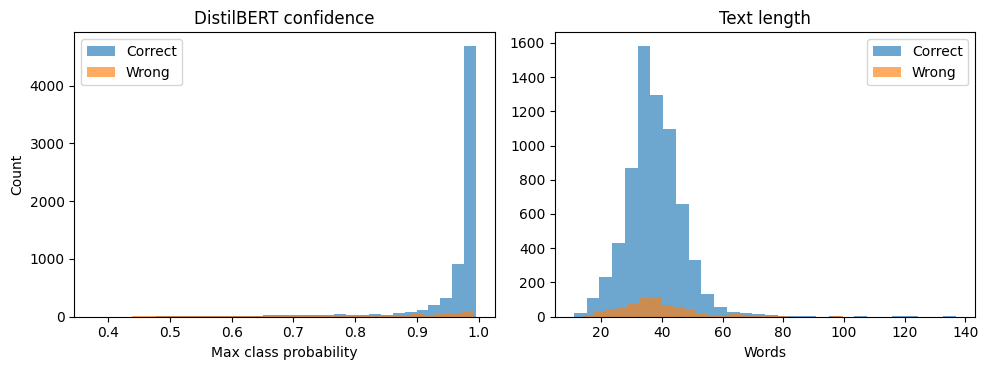

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].hist(analysis_df.loc[analysis_df["correct"], "confidence"], bins=30, alpha=0.65, label="Correct")
axes[0].hist(analysis_df.loc[~analysis_df["correct"], "confidence"], bins=30, alpha=0.65, label="Wrong")
axes[0].set_title("DistilBERT confidence")
axes[0].set_xlabel("Max class probability")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(analysis_df.loc[analysis_df["correct"], "length"], bins=30, alpha=0.65, label="Correct")
axes[1].hist(analysis_df.loc[~analysis_df["correct"], "length"], bins=30, alpha=0.65, label="Wrong")
axes[1].set_title("Text length")
axes[1].set_xlabel("Words")
axes[1].legend()

plt.tight_layout()
savefig("05_error_profile.png")
plt.show()

## 8. Bonus: Calibration Analysis

### 8.1 Expected Calibration Error
Calibration measures whether predicted confidence matches empirical correctness. This is a stretch analysis and does not change the classifier.

In [25]:
def ece_score(probs, labels, n_bins=10):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)

    rows = []
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        acc = correct[mask].mean()
        avg_conf = conf[mask].mean()
        weight = mask.mean()
        ece += weight * abs(acc - avg_conf)

        rows.append({
            "bin_low": lo,
            "bin_high": hi,
            "n": int(mask.sum()),
            "accuracy": acc,
            "confidence": avg_conf
        })

    return ece, pd.DataFrame(rows)

tfidf_ece, tfidf_cal = ece_score(tfidf_prob, true)
bert_ece, bert_cal = ece_score(bert_prob, true)

calibration_summary = pd.DataFrame([
    {"model": "TF-IDF + Logistic Regression", "ECE": tfidf_ece},
    {"model": "DistilBERT", "ECE": bert_ece}
])

calibration_summary.to_csv(os.path.join(RES_DIR, "calibration_summary.csv"), index=False)
calibration_summary.round(4)

,model,ECE
0,TF-IDF + Logistic Regression,0.1878
1,DistilBERT,0.0333


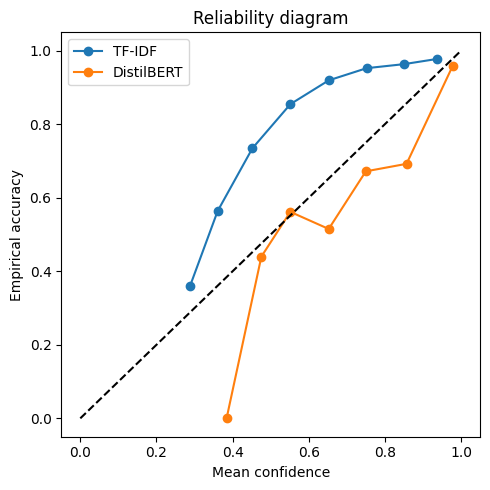

In [26]:
fig, ax = plt.subplots(figsize=(5, 5))

for name, cal in [
    ("TF-IDF", tfidf_cal),
    ("DistilBERT", bert_cal)
]:
    ax.plot(cal["confidence"], cal["accuracy"], marker="o", label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="black")
ax.set_xlabel("Mean confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Reliability diagram")
ax.legend()
plt.tight_layout()
savefig("06_reliability_diagram.png")
plt.show()

### 8.2 Temperature scaling for DistilBERT
A positive scalar temperature is selected on validation logits to reduce negative log-likelihood. Temperature scaling changes probability confidence but preserves the predicted class because dividing all logits for one example by the same positive scalar does not change their ordering.


In [27]:
val_logits = bert_final["val_eval"]["logits"]
val_labels = bert_final["val_eval"]["labels"]
test_logits = bert_test["logits"]

temperatures = np.linspace(0.5, 5.0, 46)
nll_values = []

for T in temperatures:
    probs = softmax(val_logits / T, axis=1)
    nll_values.append(log_loss(val_labels, probs, labels=list(range(len(label_names)))))

best_T = float(temperatures[int(np.argmin(nll_values))])

bert_scaled_prob = softmax(test_logits / best_T, axis=1)
bert_scaled_ece, bert_scaled_cal = ece_score(bert_scaled_prob, true)

bert_nll_before = log_loss(true, bert_prob, labels=list(range(len(label_names))))
bert_nll_after = log_loss(true, bert_scaled_prob, labels=list(range(len(label_names))))

temperature_results = pd.DataFrame([{
    "temperature": best_T,
    "distilbert_ECE_before": bert_ece,
    "distilbert_ECE_after": bert_scaled_ece,
    "distilbert_NLL_before": bert_nll_before,
    "distilbert_NLL_after": bert_nll_after
}])

temperature_results.to_csv(os.path.join(RES_DIR, "temperature_scaling_results.csv"), index=False)
temperature_results.round(4)


,temperature,distilbert_ECE_before,distilbert_ECE_after,distilbert_NLL_before,distilbert_NLL_after
0,1.2,0.0333,0.0165,0.2747,0.2681


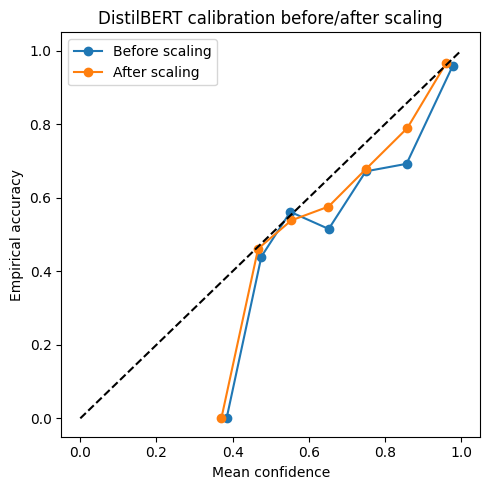

In [28]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(bert_cal["confidence"], bert_cal["accuracy"], marker="o", label="Before scaling")
ax.plot(bert_scaled_cal["confidence"], bert_scaled_cal["accuracy"], marker="o", label="After scaling")
ax.plot([0, 1], [0, 1], linestyle="--", color="black")

ax.set_xlabel("Mean confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title("DistilBERT calibration before/after scaling")
ax.legend()
plt.tight_layout()
savefig("07_temperature_scaling.png")
plt.show()

## 9.Statistical Analysis

We compare DistilBERT and TF-IDF on the same test samples using the Exact McNemar test. We also estimate a paired bootstrap 95% confidence interval for the difference in macro-F1.

In [29]:
from scipy.stats import binomtest
from sklearn.metrics import f1_score

y_true = test_df["label"].to_numpy()
pred_tfidf = np.asarray(tfidf_pred)
pred_bert = np.asarray(bert_pred)

tfidf_correct = pred_tfidf == y_true
bert_correct = pred_bert == y_true

bert_only = int(np.sum(bert_correct & ~tfidf_correct))
tfidf_only = int(np.sum(tfidf_correct & ~bert_correct))

if bert_only + tfidf_only > 0:
    mcnemar = binomtest(
        min(bert_only, tfidf_only),
        n=bert_only + tfidf_only,
        p=0.5,
        alternative="two-sided"
    )
    mcnemar_p = mcnemar.pvalue
else:
    mcnemar_p = 1.0

rng = np.random.default_rng(SEED)
n_boot = 2000
delta_f1 = []

for _ in range(n_boot):
    idx = rng.integers(0, len(y_true), len(y_true))

    f1_bert = f1_score(
        y_true[idx],
        pred_bert[idx],
        average="macro"
    )

    f1_tfidf = f1_score(
        y_true[idx],
        pred_tfidf[idx],
        average="macro"
    )

    delta_f1.append(f1_bert - f1_tfidf)

delta_f1 = np.asarray(delta_f1)

ci_low, ci_high = np.percentile(
    delta_f1,
    [2.5, 97.5]
)

observed_delta = (
    f1_score(y_true, pred_bert, average="macro")
    - f1_score(y_true, pred_tfidf, average="macro")
)

stat_results = pd.DataFrame([{
    "DistilBERT_only_correct": bert_only,
    "TFIDF_only_correct": tfidf_only,
    "McNemar_p_value": mcnemar_p,
    "Delta_macro_F1": observed_delta,
    "Bootstrap_CI_low": ci_low,
    "Bootstrap_CI_high": ci_high
}])

stat_results.to_csv(
    os.path.join(RES_DIR, "statistical_comparison.csv"),
    index=False
)

stat_results.round(5)

,DistilBERT_only_correct,TFIDF_only_correct,McNemar_p_value,Delta_macro_F1,Bootstrap_CI_low,Bootstrap_CI_high
0,424,280,0.0,0.01956,0.01277,0.02637


### 9.1 Controlled convolution, self-attention, and hybrid experiment

To answer both discussion questions with direct evidence, three lightweight classifiers are trained from scratch on the same 8,000-example AG News subset and evaluated on the same validation split:

- **Text-CNN:** token embeddings followed by a local 1-D convolution.
- **Self-attention:** token and positional embeddings followed by a self-attention block.
- **CNN + self-attention hybrid:** a 1-D convolution first creates local phrase-aware features, then a self-attention block combines those features globally.

The models use the same tokenizer, embedding dimension, training subset, optimizer family, epoch budget, and validation data. This experiment is supplementary and does not replace the project’s main TF-IDF versus DistilBERT comparison. Its purpose is to directly test the mechanisms named in the Discussion & Observation questions.


In [30]:
from torch import nn
from IPython.display import display, Markdown

DISCUSSION_TRAIN_N = FINAL_N
DISCUSSION_EPOCHS = 3
DISCUSSION_BATCH = 64
DISCUSSION_DIM = 128
DISCUSSION_HEADS = 4
DISCUSSION_KERNEL = 3
DISCUSSION_LR = 2e-3

class DiscussionDataset(Dataset):
    def __init__(self, df):
        enc = tokenizer(
            list(df["text"]),
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(df["label"].to_numpy(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

class TextCNNClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, DISCUSSION_DIM, padding_idx=tokenizer.pad_token_id)
        self.conv = nn.Conv1d(DISCUSSION_DIM, DISCUSSION_DIM, DISCUSSION_KERNEL, padding=DISCUSSION_KERNEL // 2)
        self.norm = nn.LayerNorm(DISCUSSION_DIM)
        self.classifier = nn.Linear(DISCUSSION_DIM, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = torch.relu(self.conv(x.transpose(1, 2)).transpose(1, 2))
        x = self.norm(x)
        mask = attention_mask.unsqueeze(-1).float()
        x = x.masked_fill(mask == 0, -1e4)
        pooled = x.max(dim=1).values
        return self.classifier(pooled)

class SelfAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, DISCUSSION_DIM, padding_idx=tokenizer.pad_token_id)
        self.position = nn.Embedding(MAX_LEN, DISCUSSION_DIM)
        self.attention = nn.MultiheadAttention(DISCUSSION_DIM, DISCUSSION_HEADS, batch_first=True)
        self.norm1 = nn.LayerNorm(DISCUSSION_DIM)
        self.ff = nn.Sequential(
            nn.Linear(DISCUSSION_DIM, DISCUSSION_DIM * 2),
            nn.ReLU(),
            nn.Linear(DISCUSSION_DIM * 2, DISCUSSION_DIM)
        )
        self.norm2 = nn.LayerNorm(DISCUSSION_DIM)
        self.classifier = nn.Linear(DISCUSSION_DIM, num_classes)

    def forward(self, input_ids, attention_mask):
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        x = self.embedding(input_ids) + self.position(positions)
        key_padding_mask = attention_mask == 0
        attn_out, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask, need_weights=False)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.classifier(pooled)

class HybridCNNAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, DISCUSSION_DIM, padding_idx=tokenizer.pad_token_id)
        self.position = nn.Embedding(MAX_LEN, DISCUSSION_DIM)
        self.conv = nn.Conv1d(DISCUSSION_DIM, DISCUSSION_DIM, DISCUSSION_KERNEL, padding=DISCUSSION_KERNEL // 2)
        self.conv_norm = nn.LayerNorm(DISCUSSION_DIM)
        self.attention = nn.MultiheadAttention(DISCUSSION_DIM, DISCUSSION_HEADS, batch_first=True)
        self.attn_norm = nn.LayerNorm(DISCUSSION_DIM)
        self.classifier = nn.Linear(DISCUSSION_DIM, num_classes)

    def forward(self, input_ids, attention_mask):
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        x = self.embedding(input_ids) + self.position(positions)
        x = torch.relu(self.conv(x.transpose(1, 2)).transpose(1, 2))
        x = self.conv_norm(x)
        key_padding_mask = attention_mask == 0
        attn_out, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask, need_weights=False)
        x = self.attn_norm(x + attn_out)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.classifier(pooled)

def evaluate_discussion_model(model, loader):
    model.eval()
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids, attention_mask)
            logits_all.append(logits.cpu())
            labels_all.append(labels.cpu())

    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs = softmax(logits, axis=1)
    pred = probs.argmax(axis=1)

    return {
        "logits": logits,
        "prob": probs,
        "pred": pred,
        "labels": labels,
        **classification_metrics(labels, pred)
    }

def train_discussion_model(model, train_loader, val_loader, name):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=DISCUSSION_LR)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_f1 = -1.0
    history = []
    start = time.perf_counter()

    for epoch in range(DISCUSSION_EPOCHS):
        model.train()
        losses = []

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        val_eval = evaluate_discussion_model(model, val_loader)
        history.append({
            "epoch": epoch + 1,
            "train_loss": float(np.mean(losses)),
            "val_accuracy": val_eval["accuracy"],
            "val_macro_f1": val_eval["macro_f1"]
        })

        if val_eval["macro_f1"] > best_f1:
            best_f1 = val_eval["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(name, "epoch", epoch + 1, "loss", round(np.mean(losses), 4), "val_f1", round(val_eval["macro_f1"], 4))

    model.load_state_dict(best_state)
    elapsed = time.perf_counter() - start
    final_eval = evaluate_discussion_model(model, val_loader)

    return model, pd.DataFrame(history), final_eval, elapsed

discussion_train = stratified_subset(train_part, DISCUSSION_TRAIN_N)
discussion_train_loader = DataLoader(DiscussionDataset(discussion_train), batch_size=DISCUSSION_BATCH, shuffle=True)
discussion_val_loader = DataLoader(DiscussionDataset(val_part), batch_size=DISCUSSION_BATCH, shuffle=False)

discussion_models = {
    "Text-CNN": TextCNNClassifier(len(tokenizer), len(label_names)),
    "Self-attention": SelfAttentionClassifier(len(tokenizer), len(label_names)),
    "CNN + self-attention": HybridCNNAttentionClassifier(len(tokenizer), len(label_names))
}

discussion_runs = {}
discussion_rows = []

for name, model in discussion_models.items():
    trained_model, history, val_eval, elapsed = train_discussion_model(
        model,
        discussion_train_loader,
        discussion_val_loader,
        name
    )

    discussion_runs[name] = {
        "model": trained_model,
        "history": history,
        "val_eval": val_eval
    }

    discussion_rows.append({
        "model": name,
        "train_size": DISCUSSION_TRAIN_N,
        "accuracy": val_eval["accuracy"],
        "macro_f1": val_eval["macro_f1"],
        "parameters": sum(p.numel() for p in trained_model.parameters()),
        "training_seconds": elapsed
    })

discussion_results = pd.DataFrame(discussion_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
discussion_results.to_csv(os.path.join(RES_DIR, "discussion_cnn_attention_hybrid.csv"), index=False)
discussion_results.round(4)


Text-CNN epoch 1 loss 0.9754 val_f1 0.7352
Text-CNN epoch 2 loss 0.385 val_f1 0.8091
Text-CNN epoch 3 loss 0.1557 val_f1 0.8084
Self-attention epoch 1 loss 0.9404 val_f1 0.7428
Self-attention epoch 2 loss 0.4121 val_f1 0.8029
Self-attention epoch 3 loss 0.1853 val_f1 0.8058
CNN + self-attention epoch 1 loss 0.947 val_f1 0.7342
CNN + self-attention epoch 2 loss 0.4514 val_f1 0.8031
CNN + self-attention epoch 3 loss 0.2201 val_f1 0.8094


,model,train_size,accuracy,macro_f1,parameters,training_seconds
0,CNN + self-attention,8000,0.8097,0.8094,4039556,4.6784
1,Text-CNN,8000,0.8093,0.8091,3956868,3.0678
2,Self-attention,8000,0.8072,0.8058,4056196,4.8474


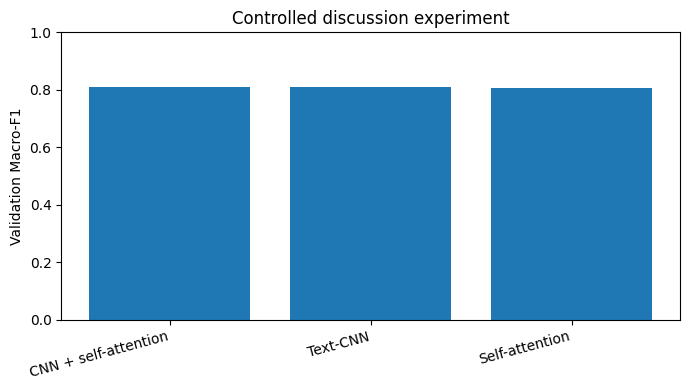

,case,text,true,Text-CNN,Self-attention,CNN_confidence,Attention_confidence
0,CNN correct / attention wrong,Make that \$9.1 billion Only a few months afte...,Business,Business,Sci/Tech,0.636691,0.542634
1,CNN correct / attention wrong,Clue to nicotine addiction found They hope the...,Sci/Tech,Sci/Tech,Business,0.751172,0.520840
2,CNN correct / attention wrong,Sun Might Have Exchanged Hangers-On With Rival...,Sci/Tech,Sci/Tech,World,0.787232,0.489465
3,Attention correct / CNN wrong,Intel Unwires Chinas Panda Playground In Wolon...,Sci/Tech,World,Sci/Tech,0.473447,0.535113
4,Attention correct / CNN wrong,Emissions pact goes forward But the tougher wo...,World,Sci/Tech,World,0.777350,0.821294
5,Attention correct / CNN wrong,Shrek 3 Moved To 2007 Dreamworks Pictures has ...,Business,Sci/Tech,Business,0.564934,0.414272


In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(discussion_results))
ax.bar(x, discussion_results["macro_f1"])
ax.set_xticks(x)
ax.set_xticklabels(discussion_results["model"], rotation=15, ha="right")
ax.set_ylabel("Validation Macro-F1")
ax.set_ylim(0, 1)
ax.set_title("Controlled discussion experiment")
fig.tight_layout()
savefig("discussion_cnn_attention_hybrid.png")
plt.show()

cnn_eval = discussion_runs["Text-CNN"]["val_eval"]
attn_eval = discussion_runs["Self-attention"]["val_eval"]
hybrid_eval = discussion_runs["CNN + self-attention"]["val_eval"]

val_true = val_part["label"].to_numpy()
cnn_pred_disc = cnn_eval["pred"]
attn_pred_disc = attn_eval["pred"]
hybrid_pred_disc = hybrid_eval["pred"]
attn_conf_disc = attn_eval["prob"].max(axis=1)
cnn_conf_disc = cnn_eval["prob"].max(axis=1)

cnn_only_idx = np.where((cnn_pred_disc == val_true) & (attn_pred_disc != val_true))[0]
attn_only_idx = np.where((attn_pred_disc == val_true) & (cnn_pred_disc != val_true))[0]

def disagreement_rows(indices, case, limit=3):
    rows = []
    for idx in indices[:limit]:
        rows.append({
            "case": case,
            "text": val_part.iloc[idx]["text"],
            "true": label_map[int(val_true[idx])],
            "Text-CNN": label_map[int(cnn_pred_disc[idx])],
            "Self-attention": label_map[int(attn_pred_disc[idx])],
            "CNN_confidence": float(cnn_conf_disc[idx]),
            "Attention_confidence": float(attn_conf_disc[idx])
        })
    return rows

discussion_disagreements = pd.DataFrame(
    disagreement_rows(cnn_only_idx, "CNN correct / attention wrong")
    + disagreement_rows(attn_only_idx, "Attention correct / CNN wrong")
)

discussion_disagreements.to_csv(os.path.join(RES_DIR, "discussion_cnn_attention_disagreements.csv"), index=False)
display(discussion_disagreements)


In [37]:
cnn_f1 = float(cnn_eval["macro_f1"])
attn_f1 = float(attn_eval["macro_f1"])
hybrid_f1 = float(hybrid_eval["macro_f1"])

if len(attn_only_idx) > 0:
    q1_idx = int(attn_only_idx[0])
elif len(cnn_only_idx) > 0:
    q1_idx = int(cnn_only_idx[0])
else:
    q1_idx = 0

q1_text = val_part.iloc[q1_idx]["text"]
q1_true = label_map[int(val_true[q1_idx])]
q1_cnn = label_map[int(cnn_pred_disc[q1_idx])]
q1_attn = label_map[int(attn_pred_disc[q1_idx])]

q1_answer = f'''
**10.1 Question 1 — Convolution versus self-attention**

Under the same 8,000-example training budget, the Text-CNN achieved Macro-F1 **{cnn_f1:.4f}** and the self-attention classifier achieved **{attn_f1:.4f}**. Their overall performance was therefore very similar.

The mechanisms differ in inductive bias. A 1-D convolution directly emphasizes local neighboring patterns and short phrase-like features, whereas self-attention can combine information from distant positions in the text.

A real disagreement from the validation set was:

> **{q1_text}**

The true class was **{q1_true}**. The Text-CNN predicted **{q1_cnn}**, while the self-attention model predicted **{q1_attn}**.

This example, together with the similar aggregate Macro-F1 scores, suggests that neither mechanism was universally superior: they sometimes used different evidence to classify the same sentence.
'''

q2_answer = f'''
**10.2 Question 2 — Hybrid convolution and attention**

The tested hybrid architecture was:

**Embedding → 1-D Convolution → Self-Attention → Masked Pooling → Classifier**

Attention was placed after convolution so that the convolution could first encode local phrase-level patterns and self-attention could then combine those features across longer distances.

Validation Macro-F1 was **{cnn_f1:.4f}** for Text-CNN, **{attn_f1:.4f}** for self-attention, and **{hybrid_f1:.4f}** for the hybrid.

The hybrid achieved the highest score, but only by a very small margin. Therefore, this experiment does not show a large performance gain from combining the mechanisms. Instead, it provides evidence that local convolutional features and global attention can be combined successfully without degrading performance. In this design, convolution contributes locality while self-attention adds long-range interaction between the locally enriched features.
'''

display(Markdown(q1_answer))
display(Markdown(q2_answer))


**10.1 Question 1 — Convolution versus self-attention**

Under the same 8,000-example training budget, the Text-CNN achieved Macro-F1 **0.8091** and the self-attention classifier achieved **0.8058**. Their overall performance was therefore very similar.

The mechanisms differ in inductive bias. A 1-D convolution directly emphasizes local neighboring patterns and short phrase-like features, whereas self-attention can combine information from distant positions in the text.

A real disagreement from the validation set was:

> **Intel Unwires Chinas Panda Playground In Wolong Sydney, Australia, 25 October, 2004 - Intel Corporation today announced it has deployed a campus-wide broadband and wireless communications network within Chinas Wolong Nature Reserve to aid researchers in the study, care and preservation of the **

The true class was **Sci/Tech**. The Text-CNN predicted **World**, while the self-attention model predicted **Sci/Tech**.

This example, together with the similar aggregate Macro-F1 scores, suggests that neither mechanism was universally superior: they sometimes used different evidence to classify the same sentence.



**10.2 Question 2 — Hybrid convolution and attention**

The tested hybrid architecture was:

**Embedding → 1-D Convolution → Self-Attention → Masked Pooling → Classifier**

Attention was placed after convolution so that the convolution could first encode local phrase-level patterns and self-attention could then combine those features across longer distances.

Validation Macro-F1 was **0.8091** for Text-CNN, **0.8058** for self-attention, and **0.8094** for the hybrid.

The hybrid achieved the highest score, but only by a very small margin. Therefore, this experiment does not show a large performance gain from combining the mechanisms. Instead, it provides evidence that local convolutional features and global attention can be combined successfully without degrading performance. In this design, convolution contributes locality while self-attention adds long-range interaction between the locally enriched features.


## 10. Discussion & Observation — Required Questions

The two answers below are rendered from the controlled experiment in Section 9.1 after the notebook is run. This keeps the discussion tied to observed validation results rather than assuming in advance that convolution, self-attention, or the hybrid must win.


## 11. Limitations
AG News is a clean four-class benchmark and does not represent all text-classification difficulties. The comparison controls labeled-data budget rather than computational budget: DistilBERT is pretrained and substantially more expensive than TF-IDF + Logistic Regression. The Transformer fine-tuning budget is compact, each data size is evaluated with one sampling/training seed, and the data-efficiency curve contains only three labeled-data budgets. ECE also depends on the chosen binning scheme. The results should not be interpreted as a universal claim that one architecture is always superior.


## 12. Reproducibility and Outputs

In [33]:
bert_final["model"].save_pretrained(os.path.join(MODEL_DIR, "distilbert_ag_news"))
tokenizer.save_pretrained(os.path.join(MODEL_DIR, "distilbert_ag_news"))

with open(os.path.join(RES_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

print("FIGURES:")
for f in sorted(os.listdir(FIG_DIR)):
    print(os.path.join(FIG_DIR, f))

print("\nRESULTS:")
for f in sorted(os.listdir(RES_DIR)):
    print(os.path.join(RES_DIR, f))

print("\nMODEL:")
print(os.path.join(MODEL_DIR, "distilbert_ag_news"))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FIGURES:
/kaggle/working/figures/01_class_distribution.png
/kaggle/working/figures/02_transformer_validation_curves.png
/kaggle/working/figures/03_data_efficiency_curve.png
/kaggle/working/figures/04_confusion_matrices.png
/kaggle/working/figures/05_error_profile.png
/kaggle/working/figures/06_reliability_diagram.png
/kaggle/working/figures/07_temperature_scaling.png
/kaggle/working/figures/discussion_cnn_attention_hybrid.png

RESULTS:
/kaggle/working/results/calibration_summary.csv
/kaggle/working/results/discussion_cnn_attention_disagreements.csv
/kaggle/working/results/discussion_cnn_attention_hybrid.csv
/kaggle/working/results/error_profile_summary.csv
/kaggle/working/results/exact_mcnemar_test.csv
/kaggle/working/results/final_model_summary.csv
/kaggle/working/results/hypothesis_decision_validation.csv
/kaggle/working/results/label_map.json
/kaggle/working/results/per_class_model_comparison.csv
/kaggle/working/results/representative_error_cases.csv
/kaggle/working/results/statisti

In [34]:
zip_path = shutil.make_archive(
    os.path.join(BASE_DIR, "tf1_project_figures"),
    "zip",
    FIG_DIR
)
print("Created:", zip_path)

Created: /kaggle/working/tf1_project_figures.zip


In [35]:
zip_path = shutil.make_archive(
    os.path.join(BASE_DIR, "tf1_project_results"),
    "zip",
    RES_DIR
)
print("Created:", zip_path)

Created: /kaggle/working/tf1_project_results.zip
